In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm

RANDOM_SEED = 2026
FEATURE_COLUMNS = [f"f{i}" for i in range(12)]
SPECIAL_COLUMNS = ["treatment", "exposure", "visit", "conversion"]
EXPECTED_COLUMNS = FEATURE_COLUMNS + SPECIAL_COLUMNS

## Task 4: Load the data

Loaded the three prepared files from `data/`, already split into train/validation/test by our challenge advisor. Used `../data/train.csv.gz` etc since the notebook lives one level down inside `notebooks/`. pandas reads the gzip-compressed files directly, no manual decompression needed.

Checked that the columns match what we expect: the 12 anonymized features (`f0`-`f11`) plus the 4 special columns (`treatment`, `exposure`, `visit`, `conversion`).

**Results:** train has 700,000 rows, validation and test each have 150,000 rows, all with 16 columns. Matches exactly what `data/README.md` said to expect.


In [3]:


train_df = pd.read_csv("../data/train.csv.gz")
val_df = pd.read_csv("../data/validation.csv.gz")
test_df = pd.read_csv("../data/test.csv.gz")

print(train_df.shape, val_df.shape, test_df.shape)
assert set(train_df.columns) == set(EXPECTED_COLUMNS), "columns don't match what the notebook expects"
train_df.head()

(700000, 16) (150000, 16) (150000, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,18.255007,10.059654,8.873602,3.907662,10.280525,4.115453,-7.011752,4.833815,3.895862,13.190056,5.300375,-0.168679,1,0,0,0
1,25.315285,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,22.340863,10.059654,8.214383,4.679882,10.280525,4.115453,-10.006574,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
3,20.831647,10.059654,8.944858,4.679882,11.561050,4.115453,-5.987667,4.833815,3.849228,13.190056,6.349310,-0.168679,1,0,0,0
4,12.616365,10.059654,8.985145,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,-0.168679,1,0,0,0


## Task 5: Review the data dictionary

Read through `data_dictionary.md` to understand what each column means and how we're allowed to use it. Key things that affect the rest of the project:

- `visit` is the primary outcome we're measuring. `conversion` is only a secondary/optional outcome.
- `exposure` is a diagnostic column only. It tells us whether someone was actually shown the ad after being assigned to treatment, but we can't use it as a model feature or filter our analysis by it.
- `f0` through `f11` are the only columns we use as model inputs. They're anonymized on purpose so we can't map them back to anything identifiable.

Also confirmed our actual data matches what the dictionary describes:

```python
train_df[["treatment", "exposure", "visit", "conversion"]].mean()
```

**Results:** treatment rate about 85%, visit rate about 4.7%, conversion rate about 0.28%, exposure rate about 3%. All consistent with the documentation.

In [4]:
train_df[["treatment", "exposure", "visit", "conversion"]].mean()

treatment     0.849953
exposure      0.030480
visit         0.046939
conversion    0.002839
dtype: float64

## Task 6: Confirm the splits are consistent

Since train/validation/test were already split for us, this task was about verifying that split actually worked, meaning all three files should show similar treatment and outcome rates. If one split had a noticeably different treatment rate, comparisons made across splits later on wouldn't be reliable.

```python
for name, split in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    rates = split[["treatment", "visit", "conversion", "exposure"]].mean()
    print(f"{name}: n={len(split)}  {rates.to_dict()}")
```

**Results:** all three splits came back nearly identical. Treatment rate about 85%, visit rate about 4.7%, conversion rate about 0.28% in every split. Confirms the split is solid and comparisons across train/validation/test can be trusted going forward.

In [5]:
for name, split in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    rates = split[["treatment", "visit", "conversion", "exposure"]].mean()
    print(f"{name}: n={len(split)}  {rates.to_dict()}")

train: n=700000  {'treatment': 0.8499528571428572, 'visit': 0.04693857142857143, 'conversion': 0.0028385714285714286, 'exposure': 0.03048}
validation: n=150000  {'treatment': 0.8499533333333333, 'visit': 0.04694, 'conversion': 0.00284, 'exposure': 0.03106}
test: n=150000  {'treatment': 0.8499533333333333, 'visit': 0.04694, 'conversion': 0.00284, 'exposure': 0.030653333333333335}


## Task 7: Random ranking baseline

Built a random ranking baseline to give us something concrete to compare a real model against in Task 8. Without a floor to compare to, "our model got X% uplift" doesn't mean anything on its own.

Assigned every record in the validation set a random score using a seeded random number generator (seed 2026, same one used throughout this notebook) so the result comes back identical every time it's rerun. Sorted everyone into 10 equal-sized groups by that score, then compared treatment vs. control visit rate within each group with a 95% confidence interval.

```python
rng = np.random.default_rng(RANDOM_SEED)
random_scores = rng.random(len(val_df))
random_baseline_table = evaluate_ranking_by_decile(random_scores, val_df["treatment"], val_df["visit"])
```

**Results:** uplift bounced around with no real pattern from decile 1 to decile 10 (0.26%, 0.52%, 1.50%, 0.86%, 0.92%, 0.32%, 1.51%, 1.89%, 0.91%, 0.95%). The top-ranked group actually had the lowest uplift of any decile, exactly what we'd expect since the ranking carries no real information. Every decile's confidence interval overlapped heavily with its neighbors, so we can't statistically say any decile is actually different from another.

The average uplift across deciles landed around 0.96%, reflecting the real overall effect of the campaign rather than anything the ranking figured out. Since random assignment can't concentrate that effect into any particular group, it spreads out roughly evenly with noise on top.

This is the floor Task 8 needs to beat. A real model should show a declining pattern from decile 1 to decile 10, with intervals that actually separate. If it doesn't look meaningfully different from this, that's a sign the model isn't picking up on real signal.

In [6]:
import numpy as np
from scipy.stats import norm

rng = np.random.default_rng(RANDOM_SEED)
random_scores = rng.random(len(val_df))

def evaluate_ranking_by_decile(scores, treatment, visit, n_groups=10):
    d = pd.DataFrame({"score": scores, "treatment": np.asarray(treatment), "visit": np.asarray(visit)})
    # deterministic tie-break: ties resolved by original row order, not randomly re-broken each run
    d["rank"] = d["score"].rank(method="first", ascending=False)
    d["group"] = pd.qcut(d["rank"], n_groups, labels=False) + 1  # group 1 = highest-ranked

    rows = []
    for g, gdf in d.groupby("group"):
        treat, ctrl = gdf[gdf.treatment == 1], gdf[gdf.treatment == 0]
        n_t, n_c = len(treat), len(ctrl)
        p_t, p_c = treat.visit.mean(), ctrl.visit.mean()
        uplift = p_t - p_c
        se = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
        z = norm.ppf(0.975)  # 1.96, for a 95% CI
        rows.append({
            "group": g, "n_treatment": n_t, "n_control": n_c,
            "treatment_visit_rate": p_t, "control_visit_rate": p_c,
            "uplift": uplift, "ci_low": uplift - z * se, "ci_high": uplift + z * se,
        })
    return pd.DataFrame(rows).sort_values("group").reset_index(drop=True)

random_baseline_table = evaluate_ranking_by_decile(random_scores, val_df["treatment"], val_df["visit"])
random_baseline_table

,group,n_treatment,n_control,treatment_visit_rate,control_visit_rate,uplift,ci_low,ci_high
0,1,12751,2249,0.047918,0.045353,0.002564,-0.006800,0.011929
1,2,12832,2168,0.046291,0.041052,0.005239,-0.003870,0.014348
2,3,12651,2349,0.050747,0.035760,0.014987,0.006560,0.023414
3,4,12745,2255,0.044488,0.035920,0.008568,0.000094,0.017042
4,5,12777,2223,0.050168,0.040936,0.009233,0.000168,0.018297
5,6,12749,2251,0.047141,0.043980,0.003160,-0.006075,0.012396
6,7,12758,2242,0.048127,0.033006,0.015120,0.006845,0.023396
7,8,12669,2331,0.049333,0.030459,0.018874,0.010944,0.026804
8,9,12770,2230,0.051292,0.042152,0.009140,-0.000036,0.018315
9,10,12791,2209,0.048472,0.038932,0.009540,0.000656,0.018424


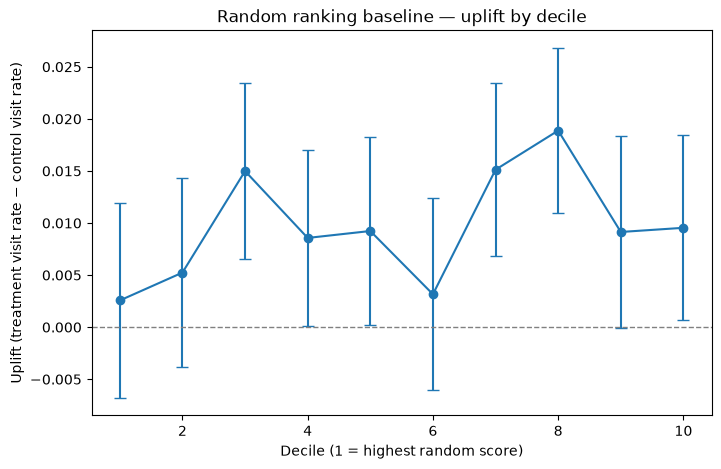

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    random_baseline_table["group"], random_baseline_table["uplift"],
    yerr=[random_baseline_table["uplift"] - random_baseline_table["ci_low"],
          random_baseline_table["ci_high"] - random_baseline_table["uplift"]],
    fmt="o-", capsize=4,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Decile (1 = highest random score)")
ax.set_ylabel("Uplift (treatment visit rate − control visit rate)")
ax.set_title("Random ranking baseline — uplift by decile")
plt.show()